# Data Wrangling con R

Learning Objectives

Select **columns** in a data frame with the "dplyr" function **select**.

Select **rows** in a data frame according to filtering conditions with the "dplyr" function **filter**.

Direct the output of one dplyr function to the input of another function with the ‘pipe’ operator **%>%**.

Add new columns to a data frame that are functions of existing columns with **mutate**.

Understand the split-apply-combine concept for data analysis.

Use summarize, group_by, and count to split a data frame into groups of observations, apply a summary statistics for each group, and then combine the results.

Join two tables by a common variable.

In [3]:
# Install and load the tidyverse library
# install.packages("tidyverse")  
library(tidyverse)

── Attaching core tidyverse packages ─────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ───────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [5]:
getwd()

[1] "/Users/magh/Desktop/Cinvestav2026/02_DataWrangling_R/script"

In [7]:
# download MS_trafficstops_bw_age.csv
download.file("http://bit.ly/MS_trafficstops_bw_age",
              "../data/MS_trafficstops_bw_age.csv")


In [8]:
# Download MS_acs2015_bw.csv
download.file("http://bit.ly/MS_acs_2015_bw",
              "../data/MS_acs2015_bw.csv")

In [ ]:
# We will be working a small subset of the data from the Stanford Open Policing Project. 
# It contains information about traffic stops in the state of Mississippi during January 2013 to mid-July of 2016
stop <- read.csv("http://bit.ly/MS_trafficstops_bw_age")
head(stop)
str(stop)

id,stop_date,county_name,county_fips,police_department,driver_gender,driver_birthdate,driver_race,officer_id,driver_age,violation
<chr>,<date>,<chr>,<dbl>,<chr>,<chr>,<date>,<chr>,<chr>,<dbl>,<chr>
MS-2013-00001,2013-01-01,Jones,28067,Mississippi Highway Patrol,male,1950-06-14,Black,J042,63,Seat belt
MS-2013-00002,2013-01-01,Lauderdale,28075,Mississippi Highway Patrol,male,1967-04-06,Black,B026,46,Careless driving
MS-2013-00003,2013-01-01,Pike,28113,Mississippi Highway Patrol,male,1974-04-15,Black,M009,39,Speeding
MS-2013-00004,2013-01-01,Hancock,28045,Mississippi Highway Patrol,male,1981-03-23,White,K035,32,Speeding
MS-2013-00005,2013-01-01,Holmes,28051,Mississippi Highway Patrol,male,1992-08-03,White,D028,20,Speeding
MS-2013-00006,2013-01-01,Jackson,28059,Mississippi Highway Patrol,female,1960-05-02,White,K023,53,Speeding


# Selecting columns and filtering rows

In [30]:
#head(select(stops, county_name, driver_gender, driver_birthdate, driver_race))
# stops %>% select(county_name, driver_gender, driver_birthdate, driver_race)
# this is the same as subsetting in base R:
# stops[c("county_name", "driver_gender", "driver_birthdate","driver_race")]
# stops[c(3,6:8)]

county_name,driver_gender,driver_birthdate,driver_race
<chr>,<chr>,<date>,<chr>
Jones,male,1950-06-14,Black
Lauderdale,male,1967-04-06,Black
Pike,male,1974-04-15,Black
Hancock,male,1981-03-23,White
Holmes,male,1992-08-03,White
Jackson,female,1960-05-02,White
Jackson,female,1953-03-16,White
Grenada,female,1993-06-14,White
Holmes,male,1947-12-11,White


In [26]:
head(select(stops, county_name, driver_gender:driver_race))

county_name,driver_gender,driver_birthdate,driver_race
<chr>,<chr>,<date>,<chr>
Jones,male,1950-06-14,Black
Lauderdale,male,1967-04-06,Black
Pike,male,1974-04-15,Black
Hancock,male,1981-03-23,White
Holmes,male,1992-08-03,White
Jackson,female,1960-05-02,White


In [28]:
head(select(stops, starts_with("driver")))

driver_gender,driver_birthdate,driver_race,driver_age
<chr>,<date>,<chr>,<dbl>
male,1950-06-14,Black,63
male,1967-04-06,Black,46
male,1974-04-15,Black,39
male,1981-03-23,White,32
male,1992-08-03,White,20
female,1960-05-02,White,53


In [40]:
#To choose rows based on specific criteria, we can use the filter() function
# head(filter(stops, county_name == "Yazoo"))
Yazoo <- stops %>% filter(county_name == "Yazoo")
head(Yazoo, 8)

id,stop_date,county_name,county_fips,police_department,driver_gender,driver_birthdate,driver_race,officer_id,driver_age,violation
<chr>,<date>,<chr>,<dbl>,<chr>,<chr>,<date>,<chr>,<chr>,<dbl>,<chr>
MS-2013-00252,2013-01-02,Yazoo,28163,Mississippi Highway Patrol,male,1950-05-04,Black,C037,63,Speeding
MS-2013-00253,2013-01-02,Yazoo,28163,Mississippi Highway Patrol,female,1967-05-29,Black,C011,46,Speeding
MS-2013-00254,2013-01-02,Yazoo,28163,Mississippi Highway Patrol,male,1986-12-21,Black,C011,26,Speeding
MS-2013-00331,2013-01-02,Yazoo,28163,Mississippi Highway Patrol,female,1986-02-01,Black,C037,27,Speeding
MS-2013-00350,2013-01-02,Yazoo,28163,Mississippi Highway Patrol,male,1994-11-21,White,C037,18,Speeding
MS-2013-00426,2013-01-03,Yazoo,28163,Mississippi Highway Patrol,male,1994-02-24,White,C014,19,Speeding
MS-2013-00427,2013-01-03,Yazoo,28163,Mississippi Highway Patrol,male,1953-07-24,White,C063,59,Speeding
MS-2013-00631,2013-01-04,Yazoo,28163,Mississippi Highway Patrol,male,1959-10-05,White,C014,53,Speeding


In [44]:
# We can also specify multiple conditions within the filter() function. 
stop_v2 <- stops %>%
filter(county_name == "Yazoo",
       driver_gender == "female",
       driver_age > 65,
       violation == "Careless driving")

head(stop_v2, 6)

id,stop_date,county_name,county_fips,police_department,driver_gender,driver_birthdate,driver_race,officer_id,driver_age,violation
<chr>,<date>,<chr>,<dbl>,<chr>,<chr>,<date>,<chr>,<chr>,<dbl>,<chr>
MS-2014-36622,2014-07-31,Yazoo,28163,Mississippi Highway Patrol,female,1945-12-29,White,C008,69,Careless driving
MS-2015-50147,2015-10-16,Yazoo,28163,Mississippi Highway Patrol,female,1949-09-11,White,C031,66,Careless driving


In [48]:
# We can also form “and” statements with the & operator instead of commas
stop_v3 <- stops %>%
filter(county_name == "Yazoo" &
       driver_gender == "female" &
       driver_age > 65 &
       violation == "Careless driving")

head(stop_v3, 6)

id,stop_date,county_name,county_fips,police_department,driver_gender,driver_birthdate,driver_race,officer_id,driver_age,violation
<chr>,<date>,<chr>,<dbl>,<chr>,<chr>,<date>,<chr>,<chr>,<dbl>,<chr>
MS-2014-36622,2014-07-31,Yazoo,28163,Mississippi Highway Patrol,female,1945-12-29,White,C008,69,Careless driving
MS-2015-50147,2015-10-16,Yazoo,28163,Mississippi Highway Patrol,female,1949-09-11,White,C031,66,Careless driving


In [52]:
# In an “or” statement, observations must meet at least one of the specified conditions. 
# To form “or” statements we use the logical operator for “or”, which is the vertical bar (|)
filter_v4 <- stops %>%
filter(county_name == "Yazoo" | county_name == "Adams")
head(filter_v4, 6)

id,stop_date,county_name,county_fips,police_department,driver_gender,driver_birthdate,driver_race,officer_id,driver_age,violation
<chr>,<date>,<chr>,<dbl>,<chr>,<chr>,<date>,<chr>,<chr>,<dbl>,<chr>
MS-2013-00252,2013-01-02,Yazoo,28163,Mississippi Highway Patrol,male,1950-05-04,Black,C037,63,Speeding
MS-2013-00253,2013-01-02,Yazoo,28163,Mississippi Highway Patrol,female,1967-05-29,Black,C011,46,Speeding
MS-2013-00254,2013-01-02,Yazoo,28163,Mississippi Highway Patrol,male,1986-12-21,Black,C011,26,Speeding
MS-2013-00331,2013-01-02,Yazoo,28163,Mississippi Highway Patrol,female,1986-02-01,Black,C037,27,Speeding
MS-2013-00350,2013-01-02,Yazoo,28163,Mississippi Highway Patrol,male,1994-11-21,White,C037,18,Speeding
MS-2013-00426,2013-01-03,Yazoo,28163,Mississippi Highway Patrol,male,1994-02-24,White,C014,19,Speeding


# Some other ways to subset rows

In [54]:
slice_v1 <- stops %>% slice(1:10)

slice_v1

id,stop_date,county_name,county_fips,police_department,driver_gender,driver_birthdate,driver_race,officer_id,driver_age,violation
<chr>,<date>,<chr>,<dbl>,<chr>,<chr>,<date>,<chr>,<chr>,<dbl>,<chr>
MS-2013-00001,2013-01-01,Jones,28067,Mississippi Highway Patrol,male,1950-06-14,Black,J042,63,Seat belt
MS-2013-00002,2013-01-01,Lauderdale,28075,Mississippi Highway Patrol,male,1967-04-06,Black,B026,46,Careless driving
MS-2013-00003,2013-01-01,Pike,28113,Mississippi Highway Patrol,male,1974-04-15,Black,M009,39,Speeding
MS-2013-00004,2013-01-01,Hancock,28045,Mississippi Highway Patrol,male,1981-03-23,White,K035,32,Speeding
MS-2013-00005,2013-01-01,Holmes,28051,Mississippi Highway Patrol,male,1992-08-03,White,D028,20,Speeding
MS-2013-00006,2013-01-01,Jackson,28059,Mississippi Highway Patrol,female,1960-05-02,White,K023,53,Speeding
MS-2013-00007,2013-01-01,Jackson,28059,Mississippi Highway Patrol,female,1953-03-16,White,K032,60,Speeding
MS-2013-00008,2013-01-01,Grenada,28043,Mississippi Highway Patrol,female,1993-06-14,White,D021,20,Speeding
MS-2013-00009,2013-01-01,Holmes,28051,Mississippi Highway Patrol,male,1947-12-11,White,R021,65,Speeding


In [56]:
# To sort rows by variables use the arrange() function
arrange_v1 <- stops %>% arrange(county_name, stop_date)

head(arrange_v1)

id,stop_date,county_name,county_fips,police_department,driver_gender,driver_birthdate,driver_race,officer_id,driver_age,violation
<chr>,<date>,<chr>,<dbl>,<chr>,<chr>,<date>,<chr>,<chr>,<dbl>,<chr>
MS-2013-07659,2013-02-09,Adams,28001,Mississippi Highway Patrol,male,1989-06-12,Black,M004,24,Speeding
MS-2013-11819,2013-03-02,Adams,28001,Mississippi Highway Patrol,female,1974-10-16,Black,M042,38,License-Permit-Insurance
MS-2013-14647,2013-03-16,Adams,28001,Mississippi Highway Patrol,female,1977-07-15,Black,M049,36,Speeding
MS-2013-15430,2013-03-20,Adams,28001,Mississippi Highway Patrol,female,1991-06-15,Black,M049,22,License-Permit-Insurance
MS-2013-18581,2013-04-06,Adams,28001,Mississippi Highway Patrol,female,1980-04-18,White,M010,33,License-Permit-Insurance
MS-2013-20016,2013-04-13,Adams,28001,Mississippi Highway Patrol,female,1996-01-14,Black,M024,17,Speeding


# Pipes

What if you wanted to filter and select on the same data? For example, lets find drivers over 85 years and only keep the violation and gender columns. There are three ways to do this: use intermediate steps, nested functions, or pipes

In [58]:
# Intermediate steps
# With intermediate steps, you create a temporary data frame and use that as input to the next function
tmp_df <- filter(stops, driver_age > 85)

select(tmp_df, violation, driver_gender)

violation,driver_gender
<chr>,<chr>
Seat belt,male
Speeding,male
Seat belt,male


In [60]:
# Nested functions
# You can also nest functions (i.e. place one function inside of another)
select(filter(stops, driver_age > 85), violation, driver_gender)

violation,driver_gender
<chr>,<chr>
Seat belt,male
Speeding,male
Seat belt,male


In [70]:
stops %>%
  filter(driver_age > 85) %>%
  select(violation, driver_gender)

violation,driver_gender
<chr>,<chr>
Seat belt,male
Speeding,male
Seat belt,male


# Add new columns

In [72]:
# Frequently you’ll want to create new columns based on the values in existing columns or. 
# For this we’ll use mutate(). We can also reassign values to an existing column with that function.
# Be aware that new and edited columns will not permanently be added to the existing data frame, munless we explicitly save the output.
# So here is an example using the year() function (from the lubridate package, which is part of the tidyverse) 
# to extract the year of the drivers’ birth
stops_columns <- stops %>% 
  mutate(birth_year = year(driver_birthdate))

head(stops_columns, 4)

id,stop_date,county_name,county_fips,police_department,driver_gender,driver_birthdate,driver_race,officer_id,driver_age,violation,birth_year
<chr>,<date>,<chr>,<dbl>,<chr>,<chr>,<date>,<chr>,<chr>,<dbl>,<chr>,<dbl>
MS-2013-00001,2013-01-01,Jones,28067,Mississippi Highway Patrol,male,1950-06-14,Black,J042,63,Seat belt,1950
MS-2013-00002,2013-01-01,Lauderdale,28075,Mississippi Highway Patrol,male,1967-04-06,Black,B026,46,Careless driving,1967
MS-2013-00003,2013-01-01,Pike,28113,Mississippi Highway Patrol,male,1974-04-15,Black,M009,39,Speeding,1974
MS-2013-00004,2013-01-01,Hancock,28045,Mississippi Highway Patrol,male,1981-03-23,White,K035,32,Speeding,1981


In [74]:
# We can keep adding columns like this, for example, the decade of the birth year
stops_columns_v2 <- stops %>% 
  mutate(birth_year = year(driver_birthdate),
         birth_cohort = floor(birth_year/10)*10) 

head(stops_columns_v2)

id,stop_date,county_name,county_fips,police_department,driver_gender,driver_birthdate,driver_race,officer_id,driver_age,violation,birth_year,birth_cohort
<chr>,<date>,<chr>,<dbl>,<chr>,<chr>,<date>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
MS-2013-00001,2013-01-01,Jones,28067,Mississippi Highway Patrol,male,1950-06-14,Black,J042,63,Seat belt,1950,1950
MS-2013-00002,2013-01-01,Lauderdale,28075,Mississippi Highway Patrol,male,1967-04-06,Black,B026,46,Careless driving,1967,1960
MS-2013-00003,2013-01-01,Pike,28113,Mississippi Highway Patrol,male,1974-04-15,Black,M009,39,Speeding,1974,1970
MS-2013-00004,2013-01-01,Hancock,28045,Mississippi Highway Patrol,male,1981-03-23,White,K035,32,Speeding,1981,1980
MS-2013-00005,2013-01-01,Holmes,28051,Mississippi Highway Patrol,male,1992-08-03,White,D028,20,Speeding,1992,1990
MS-2013-00006,2013-01-01,Jackson,28059,Mississippi Highway Patrol,female,1960-05-02,White,K023,53,Speeding,1960,1960


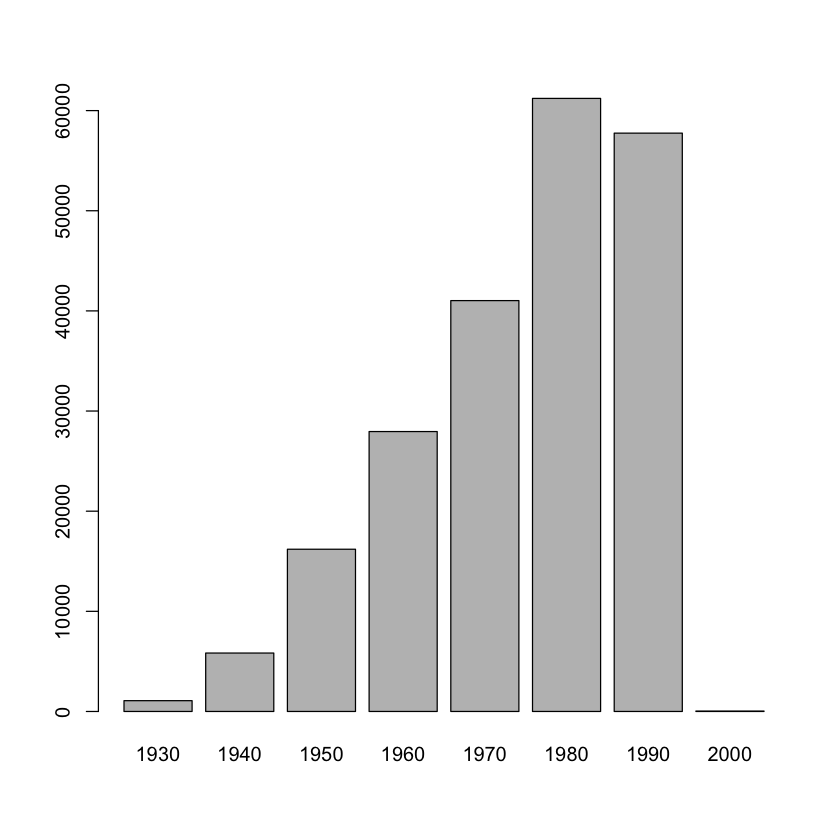

In [80]:
stops %>% 
  mutate(birth_year = year(driver_birthdate),
         birth_cohort = floor(birth_year/10)*10,
         birth_cohort = factor(birth_cohort)) %>%
    select(birth_cohort) %>% 
    plot()

In [237]:
# Mutate can also be used in conjunction with logical conditions. 
# For example, we could create a new column, where we assign everyone born after the year 2000 to a group “millenial” 
# and everyone before to “pre-millenial”
# In order to do this we take advantage of the ifelse function:
# ifelse(a_logical_condition, if_true_return_this, if_false_return_this)
stops_columns_v2 <- stops %>% 
  mutate(cohort = ifelse(year(driver_birthdate) < 2000, "pre-millenial", "millenial")) %>% 
  select(driver_birthdate, cohort)
head(stops_columns_v2)

driver_birthdate,cohort
<date>,<chr>
1950-06-14,pre-millenial
1967-04-06,pre-millenial
1974-04-15,pre-millenial
1981-03-23,pre-millenial
1992-08-03,pre-millenial
1960-05-02,pre-millenial


In [56]:
head(stops, 6)

id,stop_date,county_name,county_fips,police_department,driver_gender,driver_birthdate,driver_race,officer_id,driver_age,violation
<chr>,<date>,<chr>,<dbl>,<chr>,<chr>,<date>,<chr>,<chr>,<dbl>,<chr>
MS-2013-00001,2013-01-01,Jones,28067,Mississippi Highway Patrol,male,1950-06-14,Black,J042,63,Seat belt
MS-2013-00002,2013-01-01,Lauderdale,28075,Mississippi Highway Patrol,male,1967-04-06,Black,B026,46,Careless driving
MS-2013-00003,2013-01-01,Pike,28113,Mississippi Highway Patrol,male,1974-04-15,Black,M009,39,Speeding
MS-2013-00004,2013-01-01,Hancock,28045,Mississippi Highway Patrol,male,1981-03-23,White,K035,32,Speeding
MS-2013-00005,2013-01-01,Holmes,28051,Mississippi Highway Patrol,male,1992-08-03,White,D028,20,Speeding
MS-2013-00006,2013-01-01,Jackson,28059,Mississippi Highway Patrol,female,1960-05-02,White,K023,53,Speeding


In [58]:
# Assuming the date column is named 'stop_date' and is in Date format.
library(lubridate)

stops_filtered <- stops %>%
  filter(driver_gender == "female",        # Filter for female drivers
         driver_age == 50,                # Filter for drivers aged 50
         wday(stop_date, week_start = 1) == 1) %>%  # Filter for stops on Sunday (1)
  mutate(weekday_of_stop = wday(stop_date, week_start = 1)) %>%  # Add weekday_of_stop column
  select(violation, weekday_of_stop)  # Keep only 'violation' and 'weekday_of_stop' columns
head(stops_filtered, 5)


violation,weekday_of_stop
<chr>,<dbl>
Other or unknown,1
Speeding,1
Speeding,1
Speeding,1
Seat belt,1


# What is split-apply-combine?

In [257]:
head(stops, 6)

id,stop_date,county_name,county_fips,police_department,driver_gender,driver_birthdate,driver_race,officer_id,driver_age,violation
<chr>,<date>,<chr>,<dbl>,<chr>,<chr>,<date>,<chr>,<chr>,<dbl>,<chr>
MS-2013-00001,2013-01-01,Jones,28067,Mississippi Highway Patrol,male,1950-06-14,Black,J042,63,Seat belt
MS-2013-00002,2013-01-01,Lauderdale,28075,Mississippi Highway Patrol,male,1967-04-06,Black,B026,46,Careless driving
MS-2013-00003,2013-01-01,Pike,28113,Mississippi Highway Patrol,male,1974-04-15,Black,M009,39,Speeding
MS-2013-00004,2013-01-01,Hancock,28045,Mississippi Highway Patrol,male,1981-03-23,White,K035,32,Speeding
MS-2013-00005,2013-01-01,Holmes,28051,Mississippi Highway Patrol,male,1992-08-03,White,D028,20,Speeding
MS-2013-00006,2013-01-01,Jackson,28059,Mississippi Highway Patrol,female,1960-05-02,White,K023,53,Speeding


In [60]:
stops %>%
  group_by(driver_race) %>% # needs a dategorical variable to group by
  summarize(mean_age = mean(driver_age, na.rm=TRUE))

driver_race,mean_age
<chr>,<dbl>
Black,34.2485
White,36.2140
NA,34.5000


In [62]:
# If we wanted to remove the line where driver_race is NA we could insert a filter() in the chain
stops %>%
  filter(!is.na(driver_race)) %>% 
  group_by(driver_race) %>%
  summarize(mean_age = mean(driver_age, na.rm=TRUE))

driver_race,mean_age
<chr>,<dbl>
Black,34.2485
White,36.2140


In [64]:
stops %>% 
  filter(!is.na(driver_race)) %>%
  group_by(county_name, driver_race) %>%
  summarize(mean_age = mean(driver_age, na.rm=TRUE))

`summarise()` has grouped output by 'county_name'. You can override using the
`.groups` argument.


county_name,driver_race,mean_age
<chr>,<chr>,<dbl>
Adams,Black,36.18868
Adams,White,40.00557
Alcorn,Black,34.56197
Alcorn,White,33.63456
Amite,Black,37.45186
Amite,White,42.10075
Attala,Black,36.39361
Attala,White,38.64245
Benton,Black,34.69421


In [66]:
stops %>% 
  filter(!is.na(driver_race)) %>%
  group_by(county_name, driver_race) %>%
  summarize(mean_age = mean(driver_age, na.rm=TRUE)) %>% 
  ungroup()

`summarise()` has grouped output by 'county_name'. You can override using the
`.groups` argument.


county_name,driver_race,mean_age
<chr>,<chr>,<dbl>
Adams,Black,36.18868
Adams,White,40.00557
Alcorn,Black,34.56197
Alcorn,White,33.63456
Amite,Black,37.45186
Amite,White,42.10075
Attala,Black,36.39361
Attala,White,38.64245
Benton,Black,34.69421


In [68]:
stops %>%
  filter(!is.na(driver_race)) %>% 
  group_by(county_name, driver_race) %>%
  summarize(mean_age = mean(driver_age, na.rm=TRUE),
            sd_age = sd(driver_age, na.rm=TRUE))

`summarise()` has grouped output by 'county_name'. You can override using the
`.groups` argument.


county_name,driver_race,mean_age,sd_age
<chr>,<chr>,<dbl>,<dbl>
Adams,Black,36.18868,14.851108
Adams,White,40.00557,15.842802
Alcorn,Black,34.56197,12.931147
Alcorn,White,33.63456,13.589983
Amite,Black,37.45186,13.380819
Amite,White,42.10075,14.905282
Attala,Black,36.39361,13.754553
Attala,White,38.64245,15.462156
Benton,Black,34.69421,11.988079


In [70]:
stops %>%
  filter(!is.na(driver_race)) %>% 
  group_by(county_name, driver_race) %>%
  summarize(mean_age = mean(driver_age, na.rm=TRUE),
            sd_age = sd(driver_age, na.rm=TRUE))

`summarise()` has grouped output by 'county_name'. You can override using the
`.groups` argument.


county_name,driver_race,mean_age,sd_age
<chr>,<chr>,<dbl>,<dbl>
Adams,Black,36.18868,14.851108
Adams,White,40.00557,15.842802
Alcorn,Black,34.56197,12.931147
Alcorn,White,33.63456,13.589983
Amite,Black,37.45186,13.380819
Amite,White,42.10075,14.905282
Attala,Black,36.39361,13.754553
Attala,White,38.64245,15.462156
Benton,Black,34.69421,11.988079


In [72]:
stops %>%
  filter(!is.na(driver_race)) %>% 
  group_by(county_name, driver_race) %>%
  summarize(mean_age = mean(driver_age, na.rm=TRUE),
            sd_age = sd(driver_age, na.rm=TRUE)) %>% 
  arrange(desc(mean_age))

`summarise()` has grouped output by 'county_name'. You can override using the
`.groups` argument.


county_name,driver_race,mean_age,sd_age
<chr>,<chr>,<dbl>,<dbl>
Amite,White,42.10075,14.905282
Quitman,White,42.00146,16.648067
Sharkey,White,41.13534,14.150077
Coahoma,White,40.71964,15.737035
Warren,White,40.53941,15.123009
Claiborne,White,40.45455,15.351513
Issaquena,White,40.36484,13.743362
Yazoo,White,40.30844,15.129081
Adams,White,40.00557,15.842802


# Tallying

In [80]:
head(stops %>%
  count(officer_id))

officer_id,n
<chr>,<int>
A003,1
A004,5
A005,4
A006,3
A007,128
A008,9


Bu default, count will name the column with the counts n. We can change this by explicitly providing a value for the name argument:

In [82]:
head(stops %>%
  count(officer_id, name = "n_stops"))

officer_id,n_stops
<chr>,<int>
A003,1
A004,5
A005,4
A006,3
A007,128
A008,9


In [86]:
head(stops %>%
  count(officer_id, name = "n_stops", sort = TRUE))

officer_id,n_stops
<chr>,<int>
C055,2940
H038,2036
D028,1937
D025,1919
G040,1910
M003,1852


In [88]:
stops %>%
  group_by(officer_id) %>%
  summarize(n_stops = n()) %>% # n() returns the group size
  arrange(desc(n_stops))

stops %>%
  group_by(officer_id) %>% 
  tally(sort = TRUE, name = "n_stops") # tally() requires group_by before counting

officer_id,n_stops
<chr>,<int>
C055,2940
H038,2036
D028,1937
D025,1919
G040,1910
M003,1852
H044,1720
H001,1657
M031,1602


officer_id,n_stops
<chr>,<int>
C055,2940
H038,2036
D028,1937
D025,1919
G040,1910
M003,1852
H044,1720
H001,1657
M031,1602


In [90]:
head(stops %>%
  count(officer_id, violation, name = "n_stops"))

officer_id,violation,n_stops
<chr>,<chr>,<int>
A003,Speeding,1
A004,Careless driving,1
A004,Seat belt,2
A004,Speeding,2
A005,License-Permit-Insurance,3
A005,Other or unknown,1


# Joining two tables

It is not uncommon that we have our data spread out in different tables and need to bring those together for analysis. In this example we will combine the numbers of stops for black and white drivers per county together with the numbers of the black and white total population for these counties. The population data are the estimated values of the 5 year average from the 2011-2015 American Community Survey (ACS):

In [92]:
acs <- read_csv("../data/MS_acs2015_bw.csv")
acs

Rows: 82 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): County
dbl (4): FIPS, black_pop, white_pop, bw_pop

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


County,FIPS,black_pop,white_pop,bw_pop
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Jones,28067,19711,47154,66865
Lauderdale,28075,33893,43482,77375
Pike,28113,21028,18282,39310
Hancock,28045,4172,39686,43858
Holmes,28051,15498,3105,18603
Jackson,28059,30704,101686,132390
Grenada,28043,9417,11991,21408
Scott,28123,10562,16920,27482
Wayne,28153,8015,12154,20169


In [96]:
# In a first step we count all the stops per county
head(stops %>% 
  count(county_name, name = "n_stops"))

county_name,n_stops
<chr>,<int>
Adams,942
Alcorn,3345
Amite,2921
Attala,4203
Benton,214
Bolivar,4526


We will then pipe this into our next operation where we bring the two tables together. We will use left_join, which returns all rows from the left table, and all columns from the left and the right table. As ID, which uniquely identifies the corresponding records in each table we use the County names.

In [100]:
head(stops %>% 
  count(county_name, name = "n_stops") %>% 
  left_join(acs, by = c("county_name" = "County")))

county_name,n_stops,FIPS,black_pop,white_pop,bw_pop
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Adams,942,28001,17757,12856,30613
Alcorn,3345,28003,4281,31563,35844
Amite,2921,28005,5416,7395,12811
Attala,4203,28007,8194,10649,18843
Benton,214,28009,3078,5166,8244
Bolivar,4526,28011,21648,11197,32845


# Plot

Warning message:
“Removed 109 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


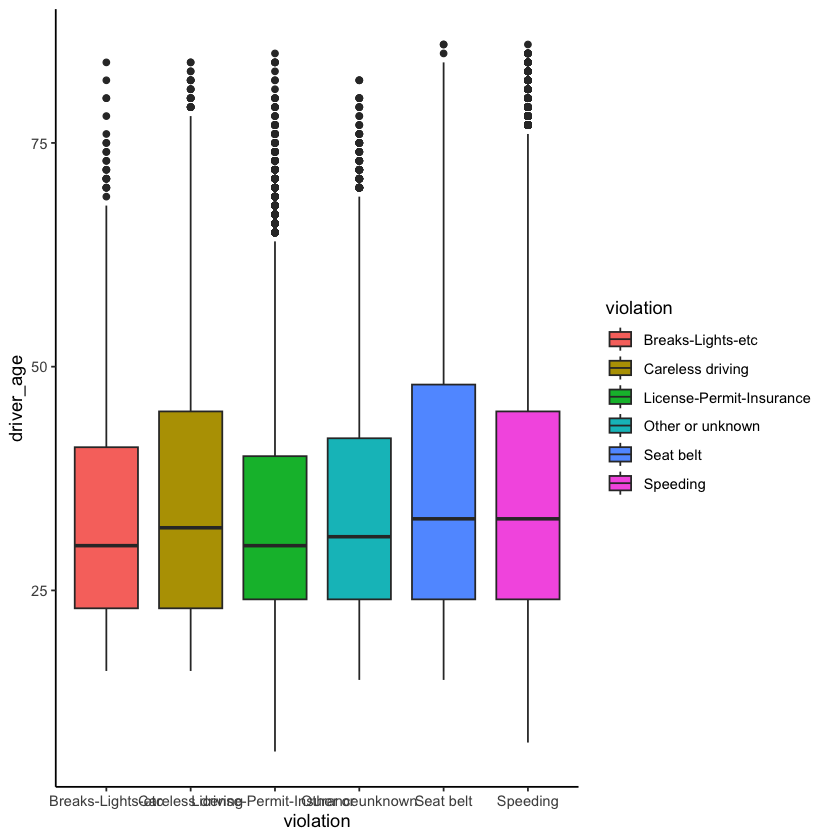

In [107]:
library(ggplot2)
plot <- ggplot(stops, aes(x = violation, y = driver_age, fill = violation)) +
  geom_boxplot() +
  theme_classic()
plot

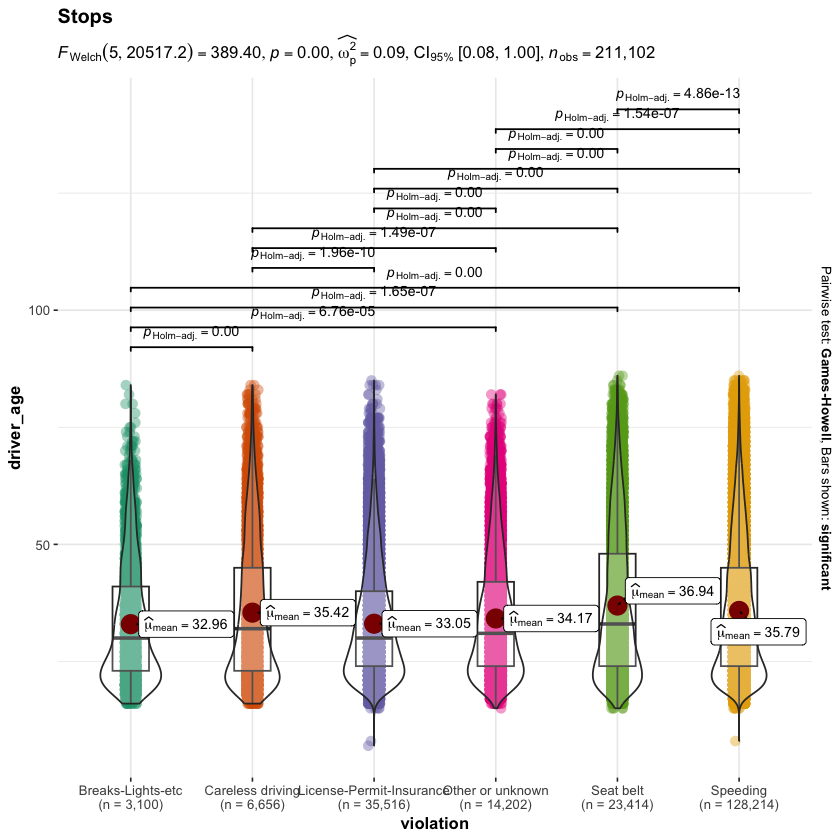

In [109]:
library(ggstatsplot)

set.seed(123)

ggbetweenstats(
  data  = stops,
  x     = violation,
  y     = driver_age,
  title = "Stops"
)

In [110]:
fig <- plot_ly(stops, x = ~violation, y = ~driver_age, color = ~violation, type = "box")
#fig <- fig %>% layout(boxmode = "group")

fig



ERROR: Error in plot_ly(stops, x = ~violation, y = ~driver_age, color = ~violation, : no se pudo encontrar la función "plot_ly"
